In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [6]:
df = pd.read_csv("fitness.csv")
df.head()


,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,health_condition,smoking_status,fitness_level
0,1,2024-01-01,56,F,165.3,53.7,Dancing,41,Low,3.3,...,3,7128,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.04
1,1,2024-01-04,56,F,165.3,53.9,Swimming,28,Low,2.9,...,7,7925,1.8,19.6,69.5,110.7,72.9,NaN,Never,0.07
2,1,2024-01-05,56,F,165.3,54.2,Swimming,21,Medium,2.6,...,7,7557,2.7,19.6,69.5,110.7,72.9,NaN,Never,0.09
3,1,2024-01-07,56,F,165.3,54.4,Weight Training,99,Medium,10.7,...,8,11120,2.6,19.6,69.5,110.7,72.9,NaN,Never,0.21
4,1,2024-01-09,56,F,165.3,54.7,Swimming,100,Medium,12.7,...,1,5406,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.33


In [7]:
features = [
    "duration_minutes",
    "calories_burned",
    "avg_heart_rate",
    "daily_steps",
    "bmi"
]

df_clean = df[features].dropna()
df_clean.head()


,duration_minutes,calories_burned,avg_heart_rate,daily_steps,bmi
0,41,3.3,103,7128,19.6
1,28,2.9,102,7925,19.6
2,21,2.6,126,7557,19.6
3,99,10.7,141,11120,19.6
4,100,12.7,112,5406,19.6


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)


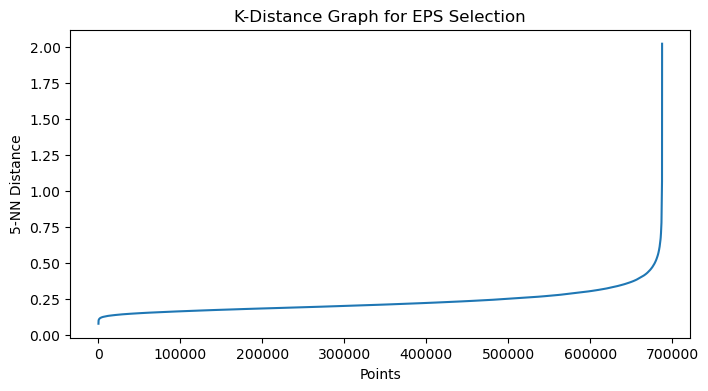

In [9]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(8,4))
plt.plot(distances)
plt.xlabel("Points")
plt.ylabel("5-NN Distance")
plt.title("K-Distance Graph for EPS Selection")
plt.show()


In [ ]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

df_clean["Cluster"] = clusters
df_clean.head()


In [ ]:
df_clean["Cluster"].value_counts()


In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(
    df_clean["calories_burned"],
    df_clean["avg_heart_rate"],
    c=df_clean["Cluster"],
    cmap="viridis",
    s=60
)

plt.xlabel("Calories Burned")
plt.ylabel("Average Heart Rate")
plt.title("DBSCAN Fitness Clustering")
plt.show()


In [ ]:
anomalies = df_clean[df_clean["Cluster"] == -1]
anomalies.head()
